In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("external_data_CL/Fang_dataset_3521_compounds.csv")

In [3]:
df

,Internal ID,Vendor ID,SMILES,CollectionName,LOG HLM_CLint (mL/min/kg),LOG MDR1-MDCK ER (B-A/A-B),LOG SOLUBILITY PH 6.8 (ug/mL),LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound),LOG PLASMA PROTEIN BINDING (RAT) (% unbound),LOG RLM_CLint (mL/min/kg)
0,Mol1,317714313,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,emolecules,0.675687,1.493167,0.089905,0.991226,0.518514,1.392169
1,Mol2,324056965,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,emolecules,0.675687,1.040780,0.550228,0.099681,0.268344,1.027920
2,Mol3,304005766,CN(c1ncc(F)cn1)[C@H]1CCCNC1,emolecules,0.675687,-0.358806,NaN,2.000000,2.000000,1.027920
3,Mol4,194963090,CC(C)(Oc1ccc(-c2cnc(N)c(-c3ccc(Cl)cc3)c2)cc1)C...,emolecules,0.675687,1.026662,1.657056,-1.158015,-1.403403,1.027920
4,Mol5,324059015,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,emolecules,0.996380,1.010597,NaN,1.015611,1.092264,1.629093
...,...,...,...,...,...,...,...,...,...,...
3516,Mol3517,43258693,O=C(c1ccc2c(c1)CCCC2)N1CCOCC1c1ccn[nH]1,emolecules,NaN,0.606813,NaN,NaN,NaN,NaN
3517,Mol3518,27448206,O=C(Nc1nc2ccccc2[nH]1)c1ccc(-n2cccc2)cc1,emolecules,NaN,-0.444495,NaN,NaN,NaN,NaN
3518,Mol3519,207150215,NC(=O)c1noc([C@@H](CCCC2CCCCC2)CC(=O)NO)n1,emolecules,0.863799,NaN,NaN,NaN,NaN,NaN
3519,Mol3520,25037224,CCCCCCCCc1ccc(CC[C@](N)(CO)COP(=O)(O)O)cc1,emolecules,0.881385,NaN,NaN,NaN,NaN,NaN


In [4]:
df_remove = df[["SMILES", "LOG HLM_CLint (mL/min/kg)"]].dropna().reset_index(drop=True)

In [5]:
df_remove

,SMILES,LOG HLM_CLint (mL/min/kg)
0,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.675687
1,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,0.675687
2,CN(c1ncc(F)cn1)[C@H]1CCCNC1,0.675687
3,CC(C)(Oc1ccc(-c2cnc(N)c(-c3ccc(Cl)cc3)c2)cc1)C...,0.675687
4,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,0.996380
...,...,...
3082,c1sc(NCC2CCCO2)nc1C12CC3CC(CC(C3)C1)C2,1.659650
3083,CCN1CCOC(C(=O)N2CCC(c3cn[nH]c3)CC2)C1,0.675687
3084,NC(=O)c1noc([C@@H](CCCC2CCCCC2)CC(=O)NO)n1,0.863799
3085,CCCCCCCCc1ccc(CC[C@](N)(CO)COP(=O)(O)O)cc1,0.881385


In [6]:
df_remove["hlm_value_unscaled"] = 10 ** df_remove["LOG HLM_CLint (mL/min/kg)"]
df_remove["hlm_value_unscaled_log10_nan"] = df_remove["LOG HLM_CLint (mL/min/kg)"]
df_remove["hlm_value_unscaled_log10_epsilon"] = df_remove["LOG HLM_CLint (mL/min/kg)"]

df_remove["hlm_value_scaled"] = 10 ** df_remove["LOG HLM_CLint (mL/min/kg)"]
df_remove["hlm_value_scaled_log10_nan"] = df_remove["LOG HLM_CLint (mL/min/kg)"]
df_remove["hlm_value_scaled_log10_epsilon"] = df_remove["LOG HLM_CLint (mL/min/kg)"]


In [7]:
df_remove

,SMILES,LOG HLM_CLint (mL/min/kg),hlm_value_unscaled,hlm_value_unscaled_log10_nan,hlm_value_unscaled_log10_epsilon,hlm_value_scaled,hlm_value_scaled_log10_nan,hlm_value_scaled_log10_epsilon
0,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.675687,4.739,0.675687,0.675687,4.739,0.675687,0.675687
1,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,0.675687,4.739,0.675687,0.675687,4.739,0.675687,0.675687
2,CN(c1ncc(F)cn1)[C@H]1CCCNC1,0.675687,4.739,0.675687,0.675687,4.739,0.675687,0.675687
3,CC(C)(Oc1ccc(-c2cnc(N)c(-c3ccc(Cl)cc3)c2)cc1)C...,0.675687,4.739,0.675687,0.675687,4.739,0.675687,0.675687
4,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,0.996380,9.917,0.996380,0.996380,9.917,0.996380,0.996380
...,...,...,...,...,...,...,...,...
3082,c1sc(NCC2CCCO2)nc1C12CC3CC(CC(C3)C1)C2,1.659650,45.672,1.659650,1.659650,45.672,1.659650,1.659650
3083,CCN1CCOC(C(=O)N2CCC(c3cn[nH]c3)CC2)C1,0.675687,4.739,0.675687,0.675687,4.739,0.675687,0.675687
3084,NC(=O)c1noc([C@@H](CCCC2CCCCC2)CC(=O)NO)n1,0.863799,7.308,0.863799,0.863799,7.308,0.863799,0.863799
3085,CCCCCCCCc1ccc(CC[C@](N)(CO)COP(=O)(O)O)cc1,0.881385,7.610,0.881385,0.881385,7.610,0.881385,0.881385


## Plot Data to see distribution

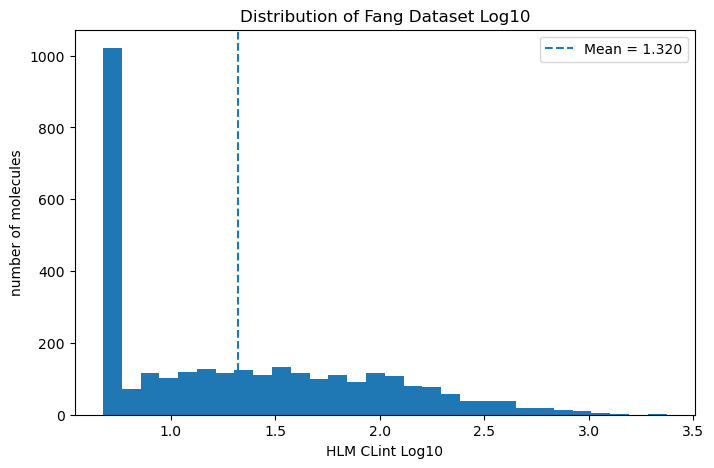

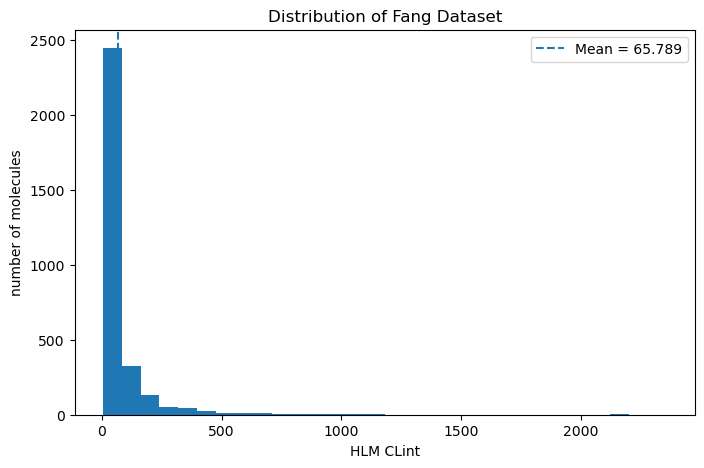

In [8]:
import matplotlib.pyplot as plt

# Mean values
mean_log10 = df_remove["hlm_value_scaled_log10_nan"].mean()
mean_value = df_remove["hlm_value_scaled"].mean()

# Plot 1: distribution of hlm_value_log10
plt.figure(figsize=(8, 5))
plt.hist(df_remove["hlm_value_scaled_log10_nan"], bins=30)
plt.axvline(mean_log10, linestyle="--", label=f"Mean = {mean_log10:.3f}")
plt.xlabel("HLM CLint Log10")
plt.ylabel("number of molecules")
plt.title("Distribution of Fang Dataset Log10")
plt.legend()
plt.show()

# Plot 2: distribution of hlm_value
plt.figure(figsize=(8, 5))
plt.hist(df_remove["hlm_value_scaled"], bins=30)
plt.axvline(mean_value, linestyle="--", label=f"Mean = {mean_value:.3f}")
plt.xlabel("HLM CLint")
plt.ylabel("number of molecules")
plt.title("Distribution of Fang Dataset")
plt.legend()
plt.show()

In [9]:
df_remove["dataset"] = "fang_dataset"
df_remove["data_year"] = "2023"
df_remove.to_csv("fang_dataset_adjusted.csv")